In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
PSRA_data = pd.read_csv('/content/PRSA_data_2010.1.1-2014.12.31.csv')
df = pd.DataFrame(PSRA_data)

df = df.dropna()
encoded_df = pd.get_dummies(df , columns = ['cbwd'] , drop_first = True)

In [ ]:
X = encoded_df[encoded_df.columns[7:14]]
Y = pd.Series(encoded_df['pm2.5'])
print(df.columns.tolist())
print(X.isna().sum())

X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size = 0.2 , random_state = 42)

['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']
TEMP       0
PRES       0
Iws        0
Is         0
Ir         0
cbwd_NW    0
cbwd_SE    0
dtype: int64


In [ ]:
model = Sequential([
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1),
])

In [ ]:
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

In [ ]:
mod = model.fit(X_train, Y_train, epochs=10,
          validation_split=0.2)

print(mod)

Epoch 1/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7789.4844 - mae: 65.6339 - val_loss: 7881.1011 - val_mae: 61.8188
Epoch 2/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7396.5464 - mae: 63.3657 - val_loss: 7348.6045 - val_mae: 61.6655
Epoch 3/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 7261.8369 - mae: 62.4978 - val_loss: 7305.8965 - val_mae: 64.1394
Epoch 4/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7198.2466 - mae: 62.0140 - val_loss: 7232.7891 - val_mae: 61.7998
Epoch 5/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7138.8784 - mae: 61.6156 - val_loss: 7194.4360 - val_mae: 59.9367
Epoch 6/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7116.7471 - mae: 61.3473 - val_loss: 7142.9971 - val_mae: 61.7439
Epoch 7/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7108.5532 - mae: 61.2837 - val_loss: 7202.5127 - val_mae: 59.3226
Epoch 8/10
836/836 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7074.2612 - mae: 61.0094 - val_loss: 7135.9849 - val_mae: 

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(Y_train, y_train_pred)
test_r2 = r2_score(Y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(Y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(Y_test, y_test_pred))

print(f"Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}  |  Test RMSE: {test_rmse:.4f}")

1044/1044 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step
Train R²: 0.1188  |  Test R²: 0.1064
Train RMSE: 85.9763  |  Test RMSE: 88.7362


Train R²: 0.1188  |  Test R²: 0.1064
Train RMSE: 85.9763  |  Test RMSE: 88.7362


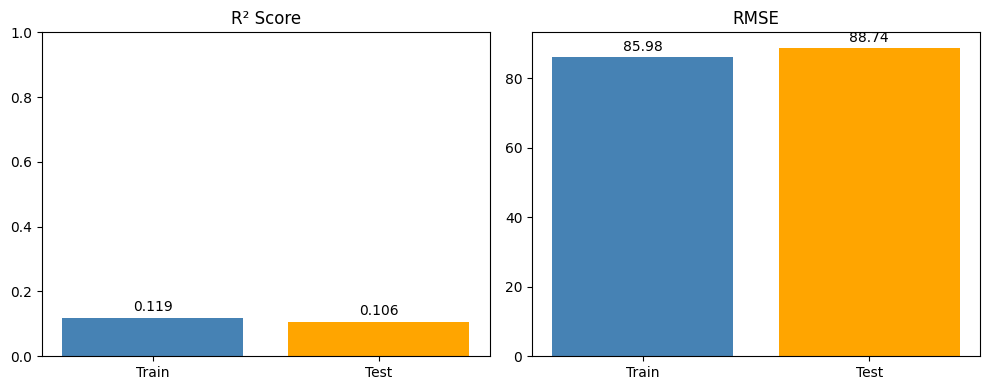

In [ ]:
from sklearn.metrics import r2_score, root_mean_squared_error


train_r2 = r2_score(Y_train, y_train_pred)
test_r2 = r2_score(Y_test, y_test_pred)
train_rmse = root_mean_squared_error(Y_train, y_train_pred)
test_rmse = root_mean_squared_error(Y_test, y_test_pred)
print(f"Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}  |  Test RMSE: {test_rmse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Train', 'Test'], [train_r2, test_r2], color=['steelblue', 'orange'])
axes[0].set_title('R² Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate([train_r2, test_r2]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center')

axes[1].bar(['Train', 'Test'], [train_rmse, test_rmse], color=['steelblue', 'orange'])
axes[1].set_title('RMSE')
for i, v in enumerate([train_rmse, test_rmse]):
    axes[1].text(i, v + max(train_rmse, test_rmse) * 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()